In [1]:
import os
import numpy as np
import pickle
import pandas as pd

In [2]:
root = os.getcwd()
root

'/home/peiretti/fair-clustering/datasets/movielens/movielens-1m'

In [3]:
path_plot = "/home/peiretti/fair-clustering/plots/movielens-1m"
path_plot

'/home/peiretti/fair-clustering/plots/movielens-1m'

In [4]:
matrix = np.load(root + "/matrix.npy").astype(int)
Sx = np.load(root + "/gender.npy").astype(int)
genres = np.load(root + "/genres.npy").astype(int)

In [5]:
genres

array([4, 1, 4, ..., 7, 7, 7])

In [6]:
matrix.shape

(6040, 3706)

In [7]:
genders, genders_counts = np.unique(Sx, return_counts=True)
print(genders)
print(genders_counts)

[0 1]
[4331 1709]


In [8]:
unique_genres = np.unique(genres)
unique_genres

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17])

In [9]:
dict_genres = {
    'Action': 0,
    'Adventure': 1,
    'Animation': 2,
    "Children's": 3,
    'Comedy': 4,
    'Crime': 5,
    'Documentary': 6,
    'Drama': 7,
    'Fantasy': 8,
    'Film-Noir': 9,
    'Horror': 10,
    'Musical': 11,
    'Mystery': 12,
    'Romance': 13,
    'Sci-Fi': 14,
    'Thriller': 15,
    'War': 16,
    'Western': 17
}

In [10]:
dict_genres

{'Action': 0,
 'Adventure': 1,
 'Animation': 2,
 "Children's": 3,
 'Comedy': 4,
 'Crime': 5,
 'Documentary': 6,
 'Drama': 7,
 'Fantasy': 8,
 'Film-Noir': 9,
 'Horror': 10,
 'Musical': 11,
 'Mystery': 12,
 'Romance': 13,
 'Sci-Fi': 14,
 'Thriller': 15,
 'War': 16,
 'Western': 17}

In [11]:
genre_names = list(dict_genres.keys())
genre_names

['Action',
 'Adventure',
 'Animation',
 "Children's",
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy',
 'Film-Noir',
 'Horror',
 'Musical',
 'Mystery',
 'Romance',
 'Sci-Fi',
 'Thriller',
 'War',
 'Western']

## Stats per gender

In [12]:
gender_likes = {gender: {int(genre): 0 for genre in unique_genres} for gender in [0, 1]}

for i, gender in enumerate(Sx):
    for j, genre in enumerate(genres):
        if matrix[i, j] >= 3:
            gender_likes[gender][genre] += 1

print(gender_likes)

{0: {0: 119537, 1: 12050, 2: 339, 3: 10914, 4: 170214, 5: 2187, 6: 4389, 7: 226459, 8: 1, 9: 578, 10: 17072, 11: 2372, 12: 1984, 13: 5341, 14: 7879, 15: 40785, 16: 1204, 17: 4628}, 1: {0: 24267, 1: 3664, 2: 105, 3: 5179, 4: 62938, 5: 634, 6: 1489, 7: 86802, 8: 0, 9: 202, 10: 3759, 11: 1412, 12: 642, 13: 3151, 14: 1420, 15: 12010, 16: 278, 17: 593}}


<Figure size 432x288 with 0 Axes>

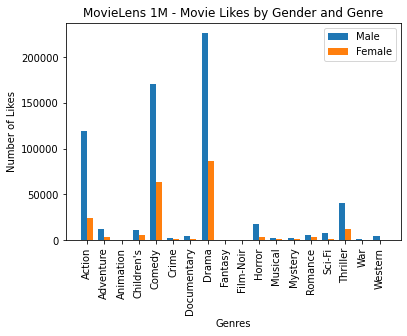

In [13]:
import matplotlib.pyplot as plt

# genre_names
genres = list(gender_likes[1].keys())
male_counts = [gender_likes[0][genre] for genre in genres]
female_counts = [gender_likes[1][genre] for genre in genres]

x = np.arange(len(genres))
width = 0.35

plt.figure()
fig, ax = plt.subplots()
ax.bar(x - width/2, male_counts, width, label='Male')
ax.bar(x + width/2, female_counts, width, label='Female')

ax.set_xlabel('Genres')
ax.set_ylabel('Number of Likes')
ax.set_title('MovieLens 1M - Movie Likes by Gender and Genre')
ax.set_xticks(x)
ax.set_xticklabels(genre_names)
plt.xticks(rotation=90)
ax.legend()
fig.savefig(path_plot + "/gender_likes.png", dpi=300, bbox_inches='tight')
#plt.show()

## Stats per age

In [14]:
Sx_age = np.load(root + "/age.npy").astype(int)
Sx_age

array([0, 2, 0, ..., 2, 1, 0])

In [15]:
age_value, age_count = np.unique(Sx_age, return_counts=True)
print(age_count)
print(age_count/np.sum(age_count))

[3421 1743  876]
[0.56639073 0.28857616 0.14503311]


In [16]:
age_likes = {age : {int(genre): 0 for genre in unique_genres} for age  in [0, 1, 2]}

for i, age in enumerate(Sx_age):
    for j, genre in enumerate(genres):
        if matrix[i, j] >= 3:
            age_likes[age][genre] += 1

print(age_likes)

{0: {0: 1293, 1: 345, 2: 216, 3: 67, 4: 138, 5: 610, 6: 228, 7: 32, 8: 40, 9: 546, 10: 547, 11: 43, 12: 41, 13: 81, 14: 40, 15: 455, 16: 400, 17: 112}, 1: {0: 554, 1: 162, 2: 78, 3: 27, 4: 59, 5: 185, 6: 116, 7: 13, 8: 13, 9: 178, 10: 285, 11: 20, 12: 33, 13: 43, 14: 26, 15: 130, 16: 262, 17: 14}, 2: {0: 153, 1: 44, 2: 45, 3: 8, 4: 17, 5: 73, 6: 47, 7: 4, 8: 4, 9: 62, 10: 128, 11: 8, 12: 5, 13: 13, 14: 8, 15: 48, 16: 129, 17: 3}}


<Figure size 432x288 with 0 Axes>

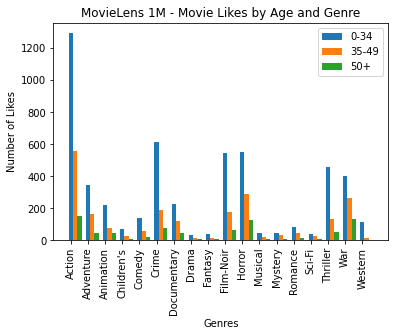

In [17]:
import matplotlib.pyplot as plt

# genre_names
genres = list(age_likes[1].keys())
young_counts = [age_likes[0][genre] for genre in genres]
middle_counts = [age_likes[1][genre] for genre in genres]
old_counts = [age_likes[2][genre] for genre in genres]

x = np.arange(len(genres))
width = 0.25
multiplier = 0

plt.figure()
fig, ax = plt.subplots()

offset = width * multiplier 
ax.bar(x + offset, young_counts, width, label='0-34')
multiplier += 1

offset = width * multiplier 
ax.bar(x + offset, middle_counts, width, label='35-49')
multiplier += 1

offset = width * multiplier 
ax.bar(x + offset, old_counts, width, label='50+')
multiplier += 1

ax.set_xlabel('Genres')
ax.set_ylabel('Number of Likes')
ax.set_title('MovieLens 1M - Movie Likes by Age and Genre')
ax.set_xticks(x)
ax.set_xticklabels(genre_names)
plt.xticks(rotation=90)
ax.legend()
#plt.show()
fig.savefig(path_plot + "/age_likes.png", dpi=300, bbox_inches='tight')